### STEP A. 데이터 준비 + 이탈 타겟 변수 생성

In [6]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

plt.rcParams['font.family'] = 'AppleGothic'
plt.rcParams['axes.unicode_minus'] = False

df = pd.read_csv('data/online_gaming_behavior_dataset.csv')

# 이탈 변수 생성
df['churn'] = df['EngagementLevel'].apply(lambda x:1 if x == 'Low' else 0)

print('이탈 유저:', df['churn'].sum(), '명')
print('잔존 유저:', sum(df['churn']==0), '명')
print('전체 이탈률:', round(df['churn'].mean()*100, 1), '%')

이탈 유저: 10324 명
잔존 유저: 29710 명
전체 이탈률: 25.8 %


### STEP B. 이탈 vs 잔존 핵심 지표

In [8]:
compare = df.groupby('churn').agg({
    'PlayTimeHours':             'mean',
    'SessionsPerWeek':           'mean',
    'AvgSessionDurationMinutes': 'mean',
    'PlayerLevel':               'mean',
    'AchievementsUnlocked':      'mean',
    'InGamePurchases':           'mean'
}).round(2)

compare.index = ['잔존(0)', '이탈(1)']
print(compare)

       PlayTimeHours  SessionsPerWeek  AvgSessionDurationMinutes  PlayerLevel  \
잔존(0)           12.0            11.19                     104.49        50.89   
이탈(1)           12.1             4.53                      66.88        46.10   

       AchievementsUnlocked  InGamePurchases  
잔존(0)                 25.17              0.2  
이탈(1)                 22.66              0.2  


### STEP C. 플레이 시간 구간별 이탈률
* 가설 1: 플레이 시간이 짧은 유저일수록 이탈률이 높을 것이다.


In [24]:
df['PlayTimeHours'].describe()

count    40034.000000
mean        12.024365
std          6.914638
min          0.000115
25%          6.067501
50%         12.008002
75%         17.963831
max         23.999592
Name: PlayTimeHours, dtype: float64

  playtime_segment  total  churned  churn_rate
0        1. 5시간 미만   8219     2074        25.2
1        2. 5~10시간   8481     2165        25.5
2       3. 10~20시간  16698     4375        26.2
3       4. 20시간 이상   6636     1710        25.8


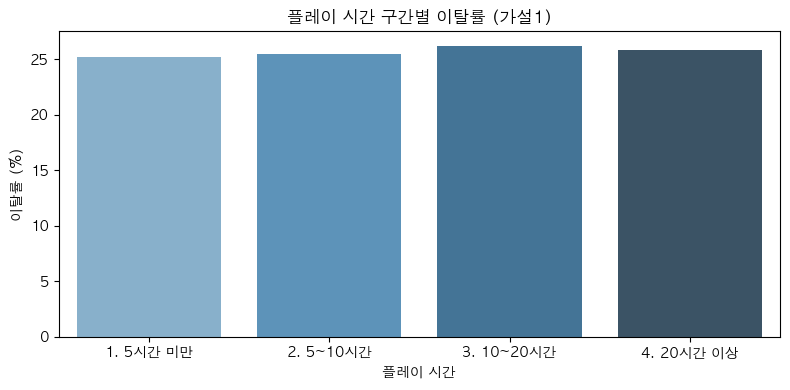

In [31]:
def playtime_segment(hours):
    if hours < 5:    return '1. 5시간 미만'
    elif hours < 10: return '2. 5~10시간'
    elif hours < 20: return '3. 10~20시간'
    else:            return '4. 20시간 이상'

df['playtime_segment'] = df['PlayTimeHours'].apply(playtime_segment)

seg = df.groupby('playtime_segment')['churn'].agg(
    total = 'count',
    churned = 'sum'
).reset_index()
seg['churn_rate'] = (seg['churned'] / seg['total'] * 100).round(1)
print(seg)

plt.figure(figsize=(8, 4))
sns.barplot(data=seg, x='playtime_segment', y='churn_rate', hue='playtime_segment', palette='Blues_d')
plt.title('플레이 시간 구간별 이탈률 (가설1)')
plt.xlabel('플레이 시간')
plt.ylabel('이탈률 (%)')
plt.tight_layout()
plt.savefig('playtime_churn_funnel.png')
plt.show()


### STEP D. 결제 여부별 이탈률
- 가설2: 결제 경험이 없는 유저가 이탈률이 높을 것이다.

   InGamePurchases  total  churned  churn_rate 구매여부
0                0  31993     8287        25.9  미결제
1                1   8041     2037        25.3   결제


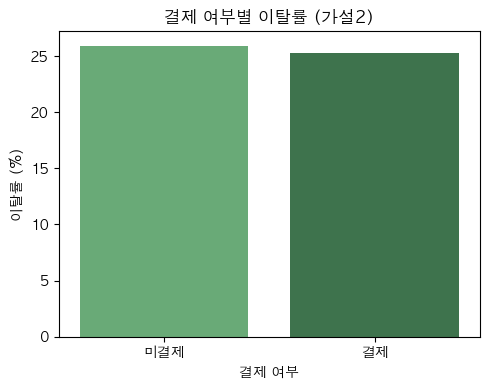

In [32]:
purchase = df.groupby('InGamePurchases')['churn'].agg(
    total = 'count',
    churned = 'sum'
).reset_index()
purchase['churn_rate'] = (purchase['churned'] / purchase['total'] * 100).round(1)
purchase['구매여부'] = purchase['InGamePurchases'].map({0: '미결제', 1: '결제'})
print(purchase)

plt.figure(figsize=(5, 4))
sns.barplot(data=purchase, x='구매여부', y='churn_rate', hue='구매여부', palette = 'Greens_d')
plt.title('결제 여부별 이탈률 (가설2)')
plt.xlabel('결제 여부')
plt.ylabel('이탈률 (%)')
plt.tight_layout()
plt.savefig('purchase_churn.png')
plt.show()


### STEP E. 주간 세션 수 구간별 이탈률 (가설3)

In [34]:
df['SessionsPerWeek'].describe()

count    40034.000000
mean         9.471774
std          5.763667
min          0.000000
25%          4.000000
50%          9.000000
75%         14.000000
max         19.000000
Name: SessionsPerWeek, dtype: float64

  session_segment  total  churned  churn_rate
0       1. 주 1~2회   5965     5034        84.4
1       2. 주 3~4회   4110     1604        39.0
2       3. 주 5~6회   4028      994        24.7
3       4. 주 7회이상  25931     2692        10.4


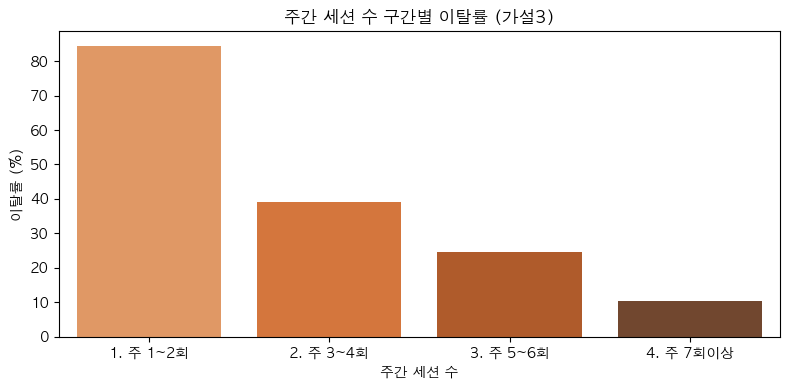

In [ ]:
def session_segment(sessions):
    if sessions <= 2:   return '1. 주 1~2회'
    elif sessions <= 4: return '2. 주 3~4회'
    elif sessions <= 6: return '3. 주 5~6회'
    else:               return '4. 주 7회이상'

df['session_segment'] = df['SessionsPerWeek'].apply(session_segment)

sess = df.groupby('session_segment')['churn'].agg(
    total = 'count',
    churned = 'sum'
).reset_index()
sess['churn_rate'] = (sess['churned'] / sess['total'] * 100).round(1)
print(sess)

plt.figure(figsize=(8, 4))
sns.barplot(data=sess, x='session_segment', y='churn_rate', hue='session_segment', palette='Oranges_d')
plt.title('주간 세션 수 구간별 이탈률 (가설3)')
plt.xlabel('주간 세션 수')
plt.ylabel('이탈률 (%)')
plt.tight_layout()
plt.savefig('session_churn.png')
plt.show()

### STEP F. 레벨 구간별 이탈률
- 가설 4: 레벨이 낮은 구간에서 이탈이 집중될 것이다

  level_segment  total  churned  churn_rate
0    1. 레벨 1~10   4075     1238        30.4
1   2. 레벨 11~30   8192     2371        28.9
2   3. 레벨 31~60  12264     3242        26.4
3    4. 레벨 61이상  15503     3473        22.4


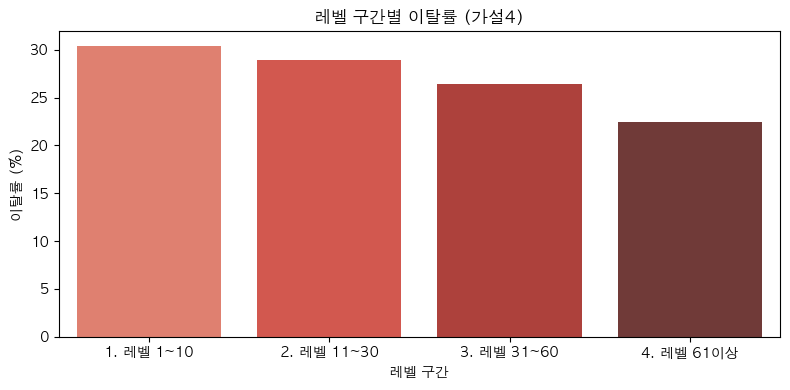

In [ ]:
def level_segment(level):
    if level <= 10:   return '1. 레벨 1~10'
    elif level <= 30: return '2. 레벨 11~30'
    elif level <= 60: return '3. 레벨 31~60'
    else:             return '4. 레벨 61이상'

df['level_segment'] = df['PlayerLevel'].apply(level_segment)

funnel = df.groupby('level_segment')['churn'].agg(
    total = 'count',
    churned = 'sum'
).reset_index()
funnel['churn_rate'] = (funnel['churned'] / funnel['total'] * 100).round(1)
print(funnel)

plt.figure(figsize=(8, 4))
sns.barplot(data=funnel, x='level_segment', y='churn_rate', hue='level_segment', palette='Reds_d')
plt.title('레벨 구간별 이탈률 (가설4)')
plt.xlabel('레벨 구간')
plt.ylabel('이탈률 (%)')
plt.tight_layout()
plt.savefig('level_churn_funnel.png')
plt.show()

### STEP G. 장르별 이탈률
- 가설 5: RPG 장르 유저가 타 장르 대비 이탈률이 낮을 것이다.

    GameGenre  total  churned  churn_rate
1         RPG   7952     2097        26.4
2  Simulation   7983     2088        26.2
3      Sports   8048     2074        25.8
0      Action   8039     2059        25.6
4    Strategy   8012     2006        25.0


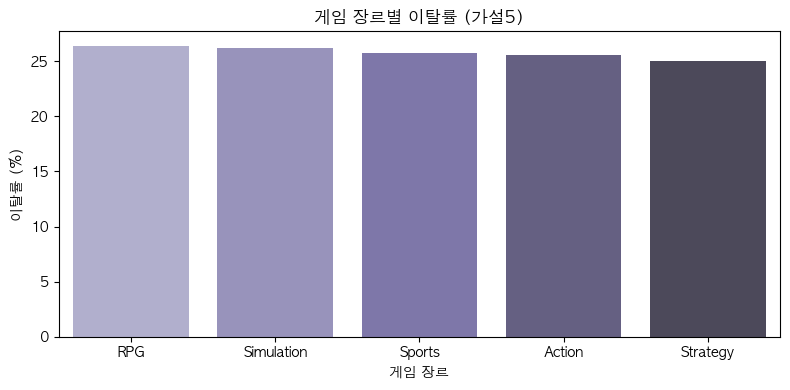

In [45]:
genre = df.groupby('GameGenre')['churn'].agg(
    total = 'count',
    churned = 'sum'
).reset_index()
genre['churn_rate'] = (genre['churned'] / genre['total'] * 100).round(1)
genre = genre.sort_values('churn_rate', ascending=False)
print(genre)

plt.figure(figsize=(8, 4))
sns.barplot(data=genre, x='GameGenre', y='churn_rate', hue='GameGenre', palette='Purples_d')
plt.title('게임 장르별 이탈률 (가설5)')
plt.xlabel('게임 장르')
plt.ylabel('이탈률 (%)')
plt.tight_layout()
plt.savefig('genre_churn.png')
plt.show()

### STEP H. 게임 난이도별 이탈률
- 가설 6: 게임 난이도가 높을수록 이탈률이 높을 것이다.

  GameDifficulty  total  churned  churn_rate
0           Easy  20015     5206        26.0
1           Hard   8008     2076        25.9
2         Medium  12011     3042        25.3


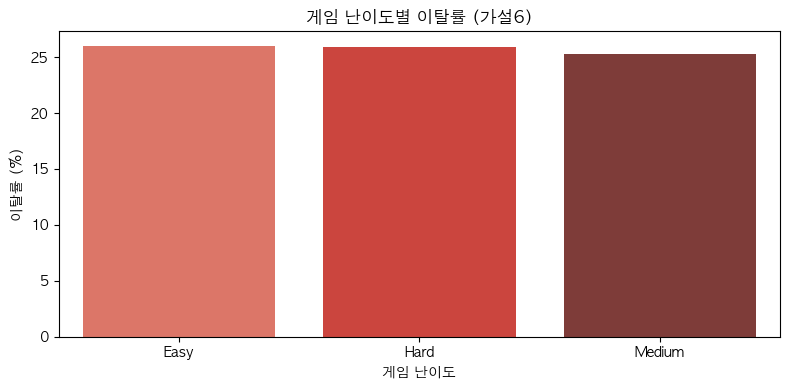

In [48]:
difficulty = df.groupby('GameDifficulty')['churn'].agg(
    total = 'count',
    churned = 'sum'
).reset_index()

difficulty['churn_rate'] = (difficulty['churned'] / difficulty['total'] * 100).round(1)
difficulty = difficulty.sort_values('churn_rate', ascending=False)
print(difficulty)

plt.figure(figsize=(8, 4))
sns.barplot(data=difficulty, x='GameDifficulty', y='churn_rate', hue='GameDifficulty', palette='Reds_d')
plt.title('게임 난이도별 이탈률 (가설6)')
plt.xlabel('게임 난이도')
plt.ylabel('이탈률 (%)')
plt.tight_layout()
plt.savefig('difficulty_churn.png')
plt.show()

### STEP I. 세션 빈도 + 세션 길이 조합별 이탈률
- 가설 7: 세션당 플레이 시간이 짧고 접속 빈도도 낮은 유저가 이탈률이 가장 높을 것이다.

      user_type  total  churned  churn_rate
2  저빈도·단시간(라이트)   9046     5761        63.7
3       저빈도·장시간   9157     2572        28.1
0       고빈도·단시간  10851     1649        15.2
1   고빈도·장시간(헤비)  10980      342         3.1


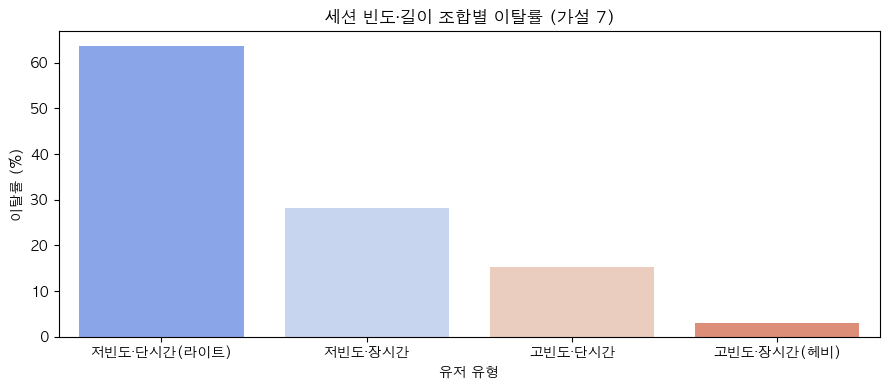

In [52]:
# 세션 빈도: 중앙값 기준으로 고/저 분류
session_median = df['SessionsPerWeek'].median()
duration_median = df['AvgSessionDurationMinutes'].median()

def user_type(row):
    high_sess = row['SessionsPerWeek'] >= session_median
    long_dur = row['AvgSessionDurationMinutes'] >= duration_median
    if high_sess and long_dur:       return '고빈도·장시간(헤비)'
    elif high_sess and not long_dur: return '고빈도·단시간'
    elif not high_sess and long_dur: return '저빈도·장시간'
    else:                            return '저빈도·단시간(라이트)'

df['user_type'] = df.apply(user_type, axis=1)

utype = df.groupby('user_type')['churn'].agg(
    total = 'count',
    churned = 'sum'
).reset_index()
utype['churn_rate'] = (utype['churned'] / utype['total'] * 100).round(1)
utype = utype.sort_values('churn_rate', ascending=False)
print(utype)

plt.figure(figsize=(9, 4))
sns.barplot(data=utype, x='user_type', y='churn_rate', hue='user_type', palette='coolwarm')
plt.title('세션 빈도·길이 조합별 이탈률 (가설 7)')
plt.xlabel('유저 유형')
plt.ylabel('이탈률 (%)')
plt.tight_layout()
plt.savefig('usertype_churn.png')
plt.show()

## 가설별 검증 결과 해석

| 가설 | 결과 | 판정 |
| :--- | :--- | :---: |
| **가설 1.** 플레이 시간 짧을수록 이탈 높음 | 25.2% ~ 26.2%, 거의 차이 없음 | <span style="color:red">❌ 기각</span> |
| **가설 2.** 미결제 유저 이탈 높음 | 미결제 25.9% vs 결제 25.3%, 거의 동일 | <span style="color:red">❌ 기각</span> |
| **가설 3.** 세션 수 적을수록 이탈 높음 | 주1~2회 84.4% vs 주7회+ 10.4%, 압도적 차이 | <span style="color:green">✅ 채택</span> |
| **가설 4.** 낮은 레벨에서 이탈 집중 | 레벨1~10 30.4% vs 61+ 22.4%, 차이 있음 | <span style="color:green">✅ 채택</span> |
| **가설 5.** RPG 이탈률 낮음 | RPG 26.4%로 오히려 가장 높음 | <span style="color:red">❌ 기각</span> |
| **가설 6.** 난이도 높을수록 이탈 높음 | Easy 26.0% Hard 25.9%, 거의 동일 | <span style="color:red">❌ 기각</span> |
| **가설 7.** 저빈도·단시간 유저 이탈 최고 | 63.7% vs 헤비유저 3.1%, 극명한 차이 | <span style="color:green">✅ 채택</span> |